# Deep Learning experiments cho bài toán phân loại trầm cảm
**Người thực hiện**: Quỳnh  

Notebook so sánh hai kiến trúc cho dữ liệu dạng bảng:

- **MLP**: baseline gọn cho dữ liệu đã scale và one-hot encode.
- **FT-Transformer**: biến từng feature thành token rồi học tương tác bằng Transformer Encoder.

Mỗi kiến trúc được thử độc lập với sáu cấu hình loss:

1. **BCE**.
2. **BCE + label smoothing**.
3. **Weighted BCE**.
4. **Weighted BCE + label smoothing**.
5. **Focal loss**.
6. **Focal loss + label smoothing**.


## 1. Thiết lập môi trường và tính tái lập

Đặt seed cho Python, NumPy và PyTorch. Nếu có GPU, notebook tự động sử dụng CUDA.


In [17]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "Notebook này cần PyTorch. Hãy chạy: pip install -r ../requirements.txt"
    ) from exc

sns.set_theme(style="whitegrid")
SEED = 42


def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


reset_seed()
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## 2. Đọc dữ liệu đã tiền xử lý

Ba tập dữ liệu phải có cùng bộ feature và cột mục tiêu `depression_label`. Tỷ lệ lớp chỉ được tính từ train set để tránh rò rỉ thông tin từ validation hoặc test.


In [18]:
TRAIN_PATH = Path("../data/processed/train_data.csv")
VAL_PATH = Path("../data/processed/validation_data.csv")
TEST_PATH = Path("../data/processed/test_data.csv")

MODEL_DIR = Path("../models/dl")
METRIC_DIR = Path("../results/metrics")
FIGURE_DIR = Path("../figures/models")
for directory in (MODEL_DIR, METRIC_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TARGET = "depression_label"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)
feature_cols = [column for column in train_df.columns if column != TARGET]

assert feature_cols == [column for column in val_df.columns if column != TARGET]
assert feature_cols == [column for column in test_df.columns if column != TARGET]

for split_name, frame in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df,
}.items():
    print(split_name, frame.shape, frame[TARGET].value_counts().sort_index().to_dict())

print("Number of features:", len(feature_cols))
train_df.head()


Train (2590, 19) {0: 2159, 1: 431}
Validation (555, 19) {0: 463, 1: 92}
Test (555, 19) {0: 463, 1: 92}
Number of features: 18


,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,platform_Both,platform_Instagram,platform_Other,platform_TikTok,sm_sleep_ratio,screen_sleep_ratio,heavy_sm_user,low_sleep,depression_label
0,-1.474207,0,1.492680,1.462525,0.386499,0.576427,-0.511030,0.002328,1.152462,1.579516,1,0,0,0,0.385484,-0.274718,1,0,0
1,1.014417,1,0.898866,-1.760734,1.642517,-1.628353,-0.340194,-1.228338,1.486274,1.579516,0,1,0,0,1.685879,2.730240,1,1,1
2,-0.478757,0,0.651443,-0.149104,-0.171731,-0.799356,-0.340194,0.002328,1.486274,1.242168,0,0,0,1,0.416277,-0.190840,0,0,0
3,0.516692,1,0.849381,-0.997330,0.386499,1.581807,1.197329,0.002328,0.484839,-0.781917,1,0,0,0,1.028599,0.695086,0,1,0
4,-0.478757,1,1.096804,-1.166976,-1.009077,-1.487247,-1.365210,0.002328,1.486274,1.579516,0,1,0,0,1.379210,-0.587976,1,1,1


In [19]:
def make_xy(frame):
    X = frame[feature_cols].to_numpy(dtype="float32")
    y = frame[TARGET].to_numpy(dtype="float32")
    return X, y


def make_loader(X, y, batch_size=128, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


X_train, y_train = make_xy(train_df)
X_val, y_val = make_xy(val_df)
X_test, y_test = make_xy(test_df)

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
positive_rate = positive_count / len(y_train)
pos_weight_value = negative_count / max(positive_count, 1)
focal_alpha = negative_count / max(negative_count + positive_count, 1)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_test, y_test)

print(f"Train positive rate: {positive_rate:.3f}")
print(f"Weighted BCE pos_weight: {pos_weight_value:.3f}")
print(f"Focal loss alpha (positive class): {focal_alpha:.3f}")


Train positive rate: 0.166
Weighted BCE pos_weight: 5.009
Focal loss alpha (positive class): 0.834


## 3. Metric và lựa chọn threshold

Model sinh ra xác suất bằng sigmoid. Threshold được dò trên validation set để tối đa hóa F1 của lớp positive; khi F1 bằng nhau, macro-F1 và recall được dùng làm tiêu chí phụ. Cùng threshold đó mới được áp dụng cho test set.


In [20]:
def predict_proba(model, loader):
    model.eval()
    probabilities, labels = [], []
    with torch.no_grad():
        for features, targets in loader:
            logits = model(features.to(DEVICE)).squeeze(1)
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
            labels.append(targets.numpy())
    return np.concatenate(probabilities), np.concatenate(labels)


def find_best_threshold(y_true, y_prob):
    rows = []
    for threshold in np.linspace(0.05, 0.95, 181):
        y_pred = (y_prob >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
        })

    threshold_table = pd.DataFrame(rows)
    best_row = threshold_table.sort_values(
        ["f1", "macro_f1", "recall", "threshold"],
        ascending=[False, False, False, True],
    ).iloc[0]
    return float(best_row["threshold"]), threshold_table


def compute_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "minority_recall": recall_score(
            y_true, y_pred, pos_label=1, zero_division=0
        ),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }


## 4. Các hàm mất mát và tham số cần tune

Sáu cấu hình giúp tách riêng tác động của class weighting và label smoothing:

- `BCE`: baseline.
- `BCE + Label Smoothing`: chỉ thêm regularization cho target.
- `Weighted BCE`: chỉ xử lý mất cân bằng lớp bằng `pos_weight`.
- `Weighted BCE + Label Smoothing`: kết hợp class weighting và target smoothing.
- `Focal Loss`: tập trung gradient vào các mẫu khó.
- `Focal Loss + Label Smoothing`: focal loss trên target đã làm mềm.

Các tham số chính có thể tune là `LABEL_SMOOTHING`, `POS_WEIGHT_SCALE`, `FOCAL_ALPHA`, `FOCAL_GAMMA`, learning rate, dropout và patience. Nên tune trên validation set; không dùng test set để chọn tham số.


In [21]:
# Điểm khởi đầu hợp lý; chỉ tune trên validation set.
LABEL_SMOOTHING = 0.05          # thử: 0.02, 0.05, 0.10
POS_WEIGHT_SCALE = 1.0          # thử: 0.75, 1.0, 1.25
FOCAL_ALPHA = focal_alpha       # thử thêm: 0.50, 0.65, focal_alpha
FOCAL_GAMMA = 2.0               # thử: 1.0, 1.5, 2.0, 3.0


def smooth_binary_targets(targets, smoothing):
    if not 0 <= smoothing < 1:
        raise ValueError("smoothing must be in [0, 1).")
    return targets * (1 - smoothing) + 0.5 * smoothing


class SmoothBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight=None, label_smoothing=0.0):
        super().__init__()
        self.register_buffer(
            "pos_weight",
            pos_weight.detach().clone() if pos_weight is not None else None,
        )
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        smoothed_targets = smooth_binary_targets(targets, self.label_smoothing)
        return nn.functional.binary_cross_entropy_with_logits(
            logits,
            smoothed_targets,
            pos_weight=self.pos_weight,
        )


class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        smoothed_targets = smooth_binary_targets(targets, self.label_smoothing)
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, smoothed_targets, reduction="none"
        )
        probabilities = torch.sigmoid(logits)
        pt = (
            smoothed_targets * probabilities
            + (1 - smoothed_targets) * (1 - probabilities)
        )
        # Alpha vẫn dựa trên nhãn gốc để giữ đúng ý nghĩa class balancing.
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        return (alpha_t * (1 - pt).pow(self.gamma) * bce).mean()


def build_loss(
    strategy,
    label_smoothing=None,
    pos_weight_scale=None,
    focal_alpha_value=None,
    focal_gamma=None,
):
    label_smoothing = (
        LABEL_SMOOTHING if label_smoothing is None else label_smoothing
    )
    pos_weight_scale = (
        POS_WEIGHT_SCALE if pos_weight_scale is None else pos_weight_scale
    )
    focal_alpha_value = (
        FOCAL_ALPHA if focal_alpha_value is None else focal_alpha_value
    )
    focal_gamma = FOCAL_GAMMA if focal_gamma is None else focal_gamma

    weighted_pos = torch.tensor(
        [pos_weight_value * pos_weight_scale],
        dtype=torch.float32,
        device=DEVICE,
    )

    if strategy == "BCE":
        return SmoothBCEWithLogitsLoss()
    if strategy == "BCE + Label Smoothing":
        return SmoothBCEWithLogitsLoss(label_smoothing=label_smoothing)
    if strategy == "Weighted BCE":
        return SmoothBCEWithLogitsLoss(pos_weight=weighted_pos)
    if strategy == "Weighted BCE + Label Smoothing":
        return SmoothBCEWithLogitsLoss(
            pos_weight=weighted_pos,
            label_smoothing=label_smoothing,
        )
    if strategy == "Focal Loss":
        return FocalLossWithLogits(
            alpha=focal_alpha_value,
            gamma=focal_gamma,
        )
    if strategy == "Focal Loss + Label Smoothing":
        return FocalLossWithLogits(
            alpha=focal_alpha_value,
            gamma=focal_gamma,
            label_smoothing=label_smoothing,
        )
    raise ValueError(f"Unknown strategy: {strategy}")


## 5. Kiến trúc model

Hai model nhận chính xác cùng input đã tiền xử lý. Trong từng kiến trúc, weights được reset bằng cùng seed trước mỗi loss experiment để giảm nhiễu do khởi tạo ngẫu nhiên.


In [22]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64, 32), dropout=0.25):
        super().__init__()
        layers = [nn.BatchNorm1d(input_dim)]
        previous_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(previous_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout),
            ])
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, features):
        return self.network(features)


class FeatureTokenizer(nn.Module):
    def __init__(self, n_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(n_features, d_token))
        self.bias = nn.Parameter(torch.zeros(n_features, d_token))
        self.feature_embedding = nn.Parameter(torch.empty(n_features, d_token))
        nn.init.xavier_uniform_(self.weight)
        nn.init.xavier_uniform_(self.feature_embedding)

    def forward(self, features):
        return (
            features.unsqueeze(-1) * self.weight.unsqueeze(0)
            + self.bias.unsqueeze(0)
            + self.feature_embedding.unsqueeze(0)
        )


class FTTransformerClassifier(nn.Module):
    def __init__(self, n_features, d_token=48, n_heads=4, n_layers=2, dropout=0.20):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_features, d_token)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=n_heads,
            dim_feedforward=d_token * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, d_token),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_token, 1),
        )
        nn.init.normal_(self.cls_token, std=0.02)

    def forward(self, features):
        tokens = self.tokenizer(features)
        cls_token = self.cls_token.expand(features.size(0), -1, -1)
        encoded = self.encoder(torch.cat([cls_token, tokens], dim=1))
        return self.head(encoded[:, 0])


def build_model(architecture):
    if architecture == "MLP":
        return MLPClassifier(input_dim=X_train.shape[1])
    if architecture == "FTTransformer":
        return FTTransformerClassifier(n_features=X_train.shape[1])
    raise ValueError(f"Unknown architecture: {architecture}")


## 6. Training loop

Early stopping theo validation F1 giúp checkpoint phù hợp với mục tiêu phân loại lớp positive. Threshold được tối ưu lại từ prediction của checkpoint tốt nhất sau khi train.


In [23]:
def train_model(model, criterion, lr, epochs=120, patience=20):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    best_state = None
    best_f1 = -np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for features, targets in train_loader:
            features, targets = features.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            logits = model(features).squeeze(1)
            loss = criterion(logits, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            train_losses.append(float(loss.item()))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for features, targets in val_loader:
                features, targets = features.to(DEVICE), targets.to(DEVICE)
                logits = model(features).squeeze(1)
                val_losses.append(float(criterion(logits, targets).item()))

        val_prob, val_true = predict_proba(model, val_loader)
        threshold, _ = find_best_threshold(val_true, val_prob)
        val_metrics = compute_metrics(val_true, val_prob, threshold)
        history.append({
            "epoch": epoch,
            "train_loss": np.mean(train_losses),
            "val_loss": np.mean(val_losses),
            "val_f1": val_metrics["f1"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_threshold": threshold,
        })

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"epoch={epoch:03d} train_loss={np.mean(train_losses):.4f} "
                f"val_loss={np.mean(val_losses):.4f} val_f1={val_metrics['f1']:.4f}"
            )

        if val_metrics["f1"] > best_f1 + 1e-4:
            best_f1 = val_metrics["f1"]
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if patience is not None and epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}: no val_f1 improvement for {patience} epochs.")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


## 7. Chạy từng experiment

Chạy cell setup một lần, sau đó chỉ chạy những experiment cần thiết. Chạy lại cùng một candidate sẽ cập nhật kết quả cũ thay vì tạo dòng trùng. `EPOCHS` là số epoch tối đa; `PATIENCE` là số epoch chờ validation F1 cải thiện trước khi early stopping. Đặt `PATIENCE = None` để luôn chạy đủ `EPOCHS`.

Các hyperparameter model được giữ cố định khi so sánh loss. Nếu muốn tune kiến trúc, nên làm ở vòng riêng sau khi đã chọn được loss strategy hợp lý.


In [41]:
EPOCHS = 120       # số epoch tối đa
PATIENCE = 20      # None = tắt early stopping và luôn chạy đủ EPOCHS

EXPERIMENT_CONFIG = {
    "MLP": {"lr": 1e-3},       # thử thêm: 3e-4, 5e-4
    "FTTransformer": {"lr": 5e-4},  # thử thêm: 1e-4, 3e-4, 1e-3
}

histories = {}
trained_models = {}
validation_rows = []

In [43]:
EXPERIMENT_CONFIG = {
    "MLP": {
        "lr": 1e-3,
        "label_smoothing": 0.05,
        "pos_weight_scale": 1.25,
        "focal_alpha_value": 0.8335907335907335,
        "focal_gamma": 1.5,
    },
    "FTTransformer": {
        "lr": 1e-3,
        "label_smoothing": 0.02,
        "pos_weight_scale": 0.50,
        "focal_alpha_value": 0.8335907335907335,
        "focal_gamma": 1.5,
    },
}

In [44]:
config = EXPERIMENT_CONFIG[architecture]
def run_experiment(architecture, strategy, epochs=EPOCHS, patience=PATIENCE):
    candidate = f"{architecture}|{strategy}"
    print(f"Training {candidate}")
    reset_seed()

    model, history = train_model(
        model=build_model(architecture),
        criterion=build_loss(
            strategy,
            label_smoothing=config["label_smoothing"],
            pos_weight_scale=config["pos_weight_scale"],
            focal_alpha_value=config["focal_alpha_value"],
            focal_gamma=config["focal_gamma"],
        ),
        lr=config["lr"],
        epochs=epochs,
        patience=patience,
    )

    val_prob, val_true = predict_proba(model, val_loader)
    threshold, threshold_table = find_best_threshold(val_true, val_prob)
    metrics = compute_metrics(val_true, val_prob, threshold)
    metrics.update({
        "candidate": candidate,
        "architecture": architecture,
        "strategy": strategy,
    })

    validation_rows[:] = [
        row for row in validation_rows if row["candidate"] != candidate
    ]
    validation_rows.append(metrics)
    histories[candidate] = history
    trained_models[candidate] = {
        "model": model,
        "threshold": threshold,
        "threshold_table": threshold_table,
    }

    print(
        f"threshold={threshold:.3f} val_f1={metrics['f1']:.4f} "
        f"precision={metrics['precision']:.4f} recall={metrics['recall']:.4f}"
    )
    return pd.DataFrame([metrics])


## 7.1 Optional hyperparameter tuning

Các cell dưới đây là **tùy chọn** và chạy độc lập. Mỗi nhóm tuning chạy lần lượt cho MLP và FT-Transformer; mỗi trial khởi tạo lại model bằng cùng seed, train trên train set, tune threshold và xếp hạng bằng validation F1. Test set không được sử dụng.

Để tuning nhanh hơn, `TUNING_EPOCHS` và `TUNING_PATIENCE` nhỏ hơn vòng train cuối. Sau khi chọn được tham số, cập nhật cell config phía trên rồi chạy lại experiment chính với `EPOCHS` đầy đủ.

Không nên mở grid quá lớn cùng lúc: tuning deep learning tốn thời gian và việc thử quá nhiều tổ hợp trên một validation set cũng có thể gây overfit validation.


In [25]:
TUNE_ARCHITECTURES = ["MLP", "FTTransformer"]
# Chỉ giữ một phần tử nếu muốn tune riêng một kiến trúc.
TUNING_EPOCHS = 50
TUNING_PATIENCE = 10

tuning_results = {}


def tune_hyperparameters(architecture, strategy, trials, tuning_name):
    rows = []
    default_lr = EXPERIMENT_CONFIG[architecture]["lr"]

    for trial_number, parameters in enumerate(trials, start=1):
        parameters = parameters.copy()
        lr = parameters.pop("lr", default_lr)
        print(
            f"\n{tuning_name} | trial {trial_number}/{len(trials)} | "
            f"lr={lr} | {parameters}"
        )

        reset_seed()
        model, history = train_model(
            model=build_model(architecture),
            criterion=build_loss(strategy, **parameters),
            lr=lr,
            epochs=TUNING_EPOCHS,
            patience=TUNING_PATIENCE,
        )
        val_prob, val_true = predict_proba(model, val_loader)
        threshold, _ = find_best_threshold(val_true, val_prob)
        metrics = compute_metrics(val_true, val_prob, threshold)
        rows.append({
            "trial": trial_number,
            "architecture": architecture,
            "strategy": strategy,
            "lr": lr,
            **parameters,
            "epochs_run": len(history),
            **{f"val_{name}": value for name, value in metrics.items()},
        })

    leaderboard = (
        pd.DataFrame(rows)
        .sort_values(["val_f1", "val_macro_f1", "val_roc_auc"], ascending=False)
        .reset_index(drop=True)
    )
    leaderboard.insert(0, "rank", np.arange(1, len(leaderboard) + 1))
    tuning_results[tuning_name] = leaderboard
    return leaderboard


def tune_all_architectures(strategy, trials, tuning_name):
    leaderboards = []
    for architecture in TUNE_ARCHITECTURES:
        table = tune_hyperparameters(
            architecture=architecture,
            strategy=strategy,
            trials=trials,
            tuning_name=f"{architecture}_{tuning_name}",
        )
        leaderboards.append(table)

    return (
        pd.concat(leaderboards, ignore_index=True)
        .sort_values(["architecture", "val_f1"], ascending=[True, False])
        .reset_index(drop=True)
    )


### Tune learning rate

Chạy với BCE để tìm vùng learning rate ổn định cho từng kiến trúc trước khi tune các loss-specific parameter.


In [26]:
lr_trials = [
    {"lr": 1e-4},
    {"lr": 3e-4},
    {"lr": 5e-4},
    {"lr": 1e-3},
]

lr_tuning = tune_all_architectures(
    strategy="BCE", trials=lr_trials, tuning_name="learning_rate"
)
lr_tuning



MLP_learning_rate | trial 1/4 | lr=0.0001 | {}
epoch=001 train_loss=0.6708 val_loss=0.6567 val_f1=0.4165
epoch=010 train_loss=0.5278 val_loss=0.5535 val_f1=0.7130
epoch=020 train_loss=0.4934 val_loss=0.5229 val_f1=0.7476
epoch=030 train_loss=0.4518 val_loss=0.4659 val_f1=0.7596
Early stopping at epoch 35: no val_f1 improvement for 10 epochs.

MLP_learning_rate | trial 2/4 | lr=0.0003 | {}
epoch=001 train_loss=0.6393 val_loss=0.6265 val_f1=0.6134
epoch=010 train_loss=0.4513 val_loss=0.4790 val_f1=0.7512
epoch=020 train_loss=0.3897 val_loss=0.4135 val_f1=0.7778
Early stopping at epoch 29: no val_f1 improvement for 10 epochs.

MLP_learning_rate | trial 3/4 | lr=0.0005 | {}
epoch=001 train_loss=0.6168 val_loss=0.6038 val_f1=0.6872
epoch=010 train_loss=0.4061 val_loss=0.4295 val_f1=0.7628
epoch=020 train_loss=0.3055 val_loss=0.3186 val_f1=0.7798
epoch=030 train_loss=0.2443 val_loss=0.2378 val_f1=0.7838
epoch=040 train_loss=0.2039 val_loss=0.2234 val_f1=0.7679
Early stopping at epoch 40: no

C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.5602 val_loss=0.4359 val_f1=0.6804
epoch=010 train_loss=0.2414 val_loss=0.2070 val_f1=0.7751
epoch=020 train_loss=0.2051 val_loss=0.1794 val_f1=0.7892
epoch=030 train_loss=0.1944 val_loss=0.1736 val_f1=0.7928
epoch=040 train_loss=0.1869 val_loss=0.1724 val_f1=0.7982
epoch=050 train_loss=0.1878 val_loss=0.1697 val_f1=0.8000

FTTransformer_learning_rate | trial 2/4 | lr=0.0003 | {}


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.4856 val_loss=0.3560 val_f1=0.6875
epoch=010 train_loss=0.1971 val_loss=0.1747 val_f1=0.7887
epoch=020 train_loss=0.1882 val_loss=0.1681 val_f1=0.7963
Early stopping at epoch 24: no val_f1 improvement for 10 epochs.

FTTransformer_learning_rate | trial 3/4 | lr=0.0005 | {}


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.4448 val_loss=0.3010 val_f1=0.7222
epoch=010 train_loss=0.1938 val_loss=0.1698 val_f1=0.7982
epoch=020 train_loss=0.1845 val_loss=0.1644 val_f1=0.7982
Early stopping at epoch 26: no val_f1 improvement for 10 epochs.

FTTransformer_learning_rate | trial 4/4 | lr=0.001 | {}


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.3839 val_loss=0.2460 val_f1=0.7368
epoch=010 train_loss=0.1938 val_loss=0.1607 val_f1=0.8148
epoch=020 train_loss=0.1805 val_loss=0.1628 val_f1=0.8145
Early stopping at epoch 20: no val_f1 improvement for 10 epochs.


,rank,trial,architecture,strategy,lr,epochs_run,val_threshold,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_minority_recall,val_roc_auc
0,1,4,FTTransformer,BCE,0.0010,20,0.625,0.927928,0.709677,0.956522,0.814815,0.885036,0.956522,0.958775
1,2,3,FTTransformer,BCE,0.0005,26,0.685,0.927928,0.720339,0.923913,0.809524,0.882540,0.923913,0.958118
2,3,2,FTTransformer,BCE,0.0003,24,0.655,0.926126,0.707317,0.945652,0.809302,0.881746,0.945652,0.955160
3,4,1,FTTransformer,BCE,0.0001,50,0.395,0.924324,0.698413,0.956522,0.807339,0.880127,0.956522,0.957789
4,1,4,MLP,BCE,0.0010,28,0.340,0.915315,0.671756,0.956522,0.789238,0.868125,0.956522,0.950770
5,2,2,MLP,BCE,0.0003,29,0.580,0.917117,0.685484,0.923913,0.787037,0.867791,0.923913,0.952625
6,3,3,MLP,BCE,0.0005,40,0.350,0.913514,0.669231,0.945652,0.783784,0.864865,0.945652,0.951686
7,4,1,MLP,BCE,0.0001,35,0.695,0.911712,0.677686,0.891304,0.769953,0.857663,0.891304,0.948610


Từ đó cho thấy learning rate 0.001 đạt hiệu quả cao nhất cho cả MLP cả FTTransformer

### Tune label smoothing


In [27]:
label_smoothing_trials = [
    {"label_smoothing": smoothing}
    for smoothing in [0.02, 0.05, 0.10]
]

label_smoothing_tuning = tune_all_architectures(
    strategy="BCE + Label Smoothing",
    trials=label_smoothing_trials,
    tuning_name="label_smoothing",
)
label_smoothing_tuning



MLP_label_smoothing | trial 1/3 | lr=0.001 | {'label_smoothing': 0.02}
epoch=001 train_loss=0.5870 val_loss=0.5675 val_f1=0.7434
epoch=010 train_loss=0.3281 val_loss=0.3314 val_f1=0.7713
Early stopping at epoch 19: no val_f1 improvement for 10 epochs.

MLP_label_smoothing | trial 2/3 | lr=0.001 | {'label_smoothing': 0.05}
epoch=001 train_loss=0.5934 val_loss=0.5734 val_f1=0.7442
epoch=010 train_loss=0.3528 val_loss=0.3507 val_f1=0.7854
epoch=020 train_loss=0.2840 val_loss=0.2860 val_f1=0.7736
Early stopping at epoch 20: no val_f1 improvement for 10 epochs.

MLP_label_smoothing | trial 3/3 | lr=0.001 | {'label_smoothing': 0.1}
epoch=001 train_loss=0.6036 val_loss=0.5827 val_f1=0.7418
epoch=010 train_loss=0.3922 val_loss=0.3830 val_f1=0.7658
epoch=020 train_loss=0.3419 val_loss=0.3371 val_f1=0.7768
Early stopping at epoch 28: no val_f1 improvement for 10 epochs.

FTTransformer_label_smoothing | trial 1/3 | lr=0.0005 | {'label_smoothing': 0.02}


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.4525 val_loss=0.3154 val_f1=0.7222
epoch=010 train_loss=0.2274 val_loss=0.2077 val_f1=0.7982
epoch=020 train_loss=0.2216 val_loss=0.2080 val_f1=0.7982
epoch=030 train_loss=0.2118 val_loss=0.1985 val_f1=0.8058
Early stopping at epoch 33: no val_f1 improvement for 10 epochs.

FTTransformer_label_smoothing | trial 2/3 | lr=0.0005 | {'label_smoothing': 0.05}


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.4641 val_loss=0.3370 val_f1=0.7189
epoch=010 train_loss=0.2694 val_loss=0.2532 val_f1=0.7982
epoch=020 train_loss=0.2650 val_loss=0.2528 val_f1=0.7945
Early stopping at epoch 24: no val_f1 improvement for 10 epochs.

FTTransformer_label_smoothing | trial 3/3 | lr=0.0005 | {'label_smoothing': 0.1}


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.4833 val_loss=0.3727 val_f1=0.7222
epoch=010 train_loss=0.3278 val_loss=0.3149 val_f1=0.7982
epoch=020 train_loss=0.3239 val_loss=0.3138 val_f1=0.7982
Early stopping at epoch 24: no val_f1 improvement for 10 epochs.


,rank,trial,architecture,strategy,lr,label_smoothing,epochs_run,val_threshold,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_minority_recall,val_roc_auc
0,1,1,FTTransformer,BCE + Label Smoothing,0.0005,0.02,33,0.580,0.927928,0.720339,0.923913,0.809524,0.882540,0.923913,0.961405
1,2,2,FTTransformer,BCE + Label Smoothing,0.0005,0.05,24,0.640,0.924324,0.698413,0.956522,0.807339,0.880127,0.956522,0.955559
2,3,3,FTTransformer,BCE + Label Smoothing,0.0005,0.10,24,0.625,0.924324,0.698413,0.956522,0.807339,0.880127,0.956522,0.955512
3,1,2,MLP,BCE + Label Smoothing,0.0010,0.05,20,0.530,0.915315,0.677165,0.934783,0.785388,0.866319,0.934783,0.952507
4,2,3,MLP,BCE + Label Smoothing,0.0010,0.10,28,0.365,0.911712,0.661654,0.956522,0.782222,0.863427,0.956522,0.952249
5,3,1,MLP,BCE + Label Smoothing,0.0010,0.02,19,0.540,0.913514,0.674603,0.923913,0.779817,0.863002,0.923913,0.950394


Hệ số label smoothing: 0.02 

### Tune weighted BCE

`pos_weight_scale=1.0` dùng đúng tỷ lệ negative/positive của train set. Scale nhỏ hơn giảm mức phạt false negative; scale lớn hơn thường tăng recall nhưng có thể giảm precision.


In [28]:
weighted_bce_trials = [
    {"pos_weight_scale": scale}
    for scale in [0.50, 0.75, 1.00, 1.25]
]

weighted_bce_tuning = tune_all_architectures(
    strategy="Weighted BCE",
    trials=weighted_bce_trials,
    tuning_name="weighted_bce",
)
weighted_bce_tuning



MLP_weighted_bce | trial 1/4 | lr=0.001 | {'pos_weight_scale': 0.5}
epoch=001 train_loss=0.6870 val_loss=0.6398 val_f1=0.7477
epoch=010 train_loss=0.3892 val_loss=0.3929 val_f1=0.7713
epoch=020 train_loss=0.3192 val_loss=0.3223 val_f1=0.7792
epoch=030 train_loss=0.2726 val_loss=0.2813 val_f1=0.7818
Early stopping at epoch 37: no val_f1 improvement for 10 epochs.

MLP_weighted_bce | trial 2/4 | lr=0.001 | {'pos_weight_scale': 0.75}
epoch=001 train_loss=0.7696 val_loss=0.6952 val_f1=0.7511
epoch=010 train_loss=0.4286 val_loss=0.4266 val_f1=0.7742
Early stopping at epoch 19: no val_f1 improvement for 10 epochs.

MLP_weighted_bce | trial 3/4 | lr=0.001 | {'pos_weight_scale': 1.0}
epoch=001 train_loss=0.8529 val_loss=0.7515 val_f1=0.7442
epoch=010 train_loss=0.4608 val_loss=0.4585 val_f1=0.7721
Early stopping at epoch 16: no val_f1 improvement for 10 epochs.

MLP_weighted_bce | trial 4/4 | lr=0.001 | {'pos_weight_scale': 1.25}
epoch=001 train_loss=0.9338 val_loss=0.8042 val_f1=0.7444
epoch

C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.6067 val_loss=0.4278 val_f1=0.7308
epoch=010 train_loss=0.3029 val_loss=0.2536 val_f1=0.8018
epoch=020 train_loss=0.2667 val_loss=0.2384 val_f1=0.7982
epoch=030 train_loss=0.2479 val_loss=0.2246 val_f1=0.8037
Early stopping at epoch 38: no val_f1 improvement for 10 epochs.

FTTransformer_weighted_bce | trial 2/4 | lr=0.0005 | {'pos_weight_scale': 0.75}


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.7132 val_loss=0.4958 val_f1=0.7282
epoch=010 train_loss=0.3600 val_loss=0.2950 val_f1=0.8018
epoch=020 train_loss=0.3074 val_loss=0.2626 val_f1=0.8091
Early stopping at epoch 22: no val_f1 improvement for 10 epochs.

FTTransformer_weighted_bce | trial 3/4 | lr=0.0005 | {'pos_weight_scale': 1.0}


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.8114 val_loss=0.5574 val_f1=0.7273
epoch=010 train_loss=0.4062 val_loss=0.3288 val_f1=0.7945
epoch=020 train_loss=0.3439 val_loss=0.2830 val_f1=0.8111
epoch=030 train_loss=0.3161 val_loss=0.2844 val_f1=0.8111
Early stopping at epoch 32: no val_f1 improvement for 10 epochs.

FTTransformer_weighted_bce | trial 4/4 | lr=0.0005 | {'pos_weight_scale': 1.25}


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.9039 val_loss=0.6158 val_f1=0.7343
epoch=010 train_loss=0.4437 val_loss=0.3558 val_f1=0.7944
epoch=020 train_loss=0.3715 val_loss=0.3054 val_f1=0.8056
epoch=030 train_loss=0.3441 val_loss=0.3199 val_f1=0.8091
Early stopping at epoch 32: no val_f1 improvement for 10 epochs.


,rank,trial,architecture,strategy,lr,pos_weight_scale,epochs_run,val_threshold,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_minority_recall,val_roc_auc
0,1,1,FTTransformer,Weighted BCE,0.0005,0.50,38,0.720,0.927928,0.706349,0.967391,0.816514,0.885835,0.967391,0.959010
1,2,3,FTTransformer,Weighted BCE,0.0005,1.00,32,0.855,0.927928,0.706349,0.967391,0.816514,0.885835,0.967391,0.957789
2,3,4,FTTransformer,Weighted BCE,0.0005,1.25,32,0.890,0.927928,0.706349,0.967391,0.816514,0.885835,0.967391,0.957273
3,4,2,FTTransformer,Weighted BCE,0.0005,0.75,22,0.855,0.927928,0.713115,0.945652,0.813084,0.884221,0.945652,0.956850
4,1,4,MLP,Weighted BCE,0.0010,1.25,33,0.825,0.920721,0.687500,0.956522,0.800000,0.875281,0.956522,0.952413
5,2,2,MLP,Weighted BCE,0.0010,0.75,19,0.755,0.913514,0.669231,0.945652,0.783784,0.864865,0.945652,0.951052
6,3,1,MLP,Weighted BCE,0.0010,0.50,37,0.595,0.911712,0.661654,0.956522,0.782222,0.863427,0.956522,0.950629
7,4,3,MLP,Weighted BCE,0.0010,1.00,16,0.810,0.913514,0.674603,0.923913,0.779817,0.863002,0.923913,0.951733


Pos_weight: 0.5 cho FT Transformer, 1.25 cho MLP

### Tune focal loss

`alpha` điều chỉnh cân bằng lớp; `gamma` điều chỉnh mức tập trung vào mẫu khó. Grid dưới đây có 9 trial và có thể giảm bớt nếu chạy CPU.


In [30]:
focal_trials = [
    {"focal_alpha_value": alpha, "focal_gamma": gamma}
    for alpha in [0.50, 0.65, focal_alpha]
    for gamma in [1.0, 1.5, 2.0]
]

focal_tuning = tune_all_architectures(
    strategy="Focal Loss", trials=focal_trials, tuning_name="focal_loss"
)
focal_tuning



MLP_focal_loss | trial 1/9 | lr=0.001 | {'focal_alpha_value': 0.5, 'focal_gamma': 1.0}
epoch=001 train_loss=0.1467 val_loss=0.1324 val_f1=0.7525
epoch=010 train_loss=0.0725 val_loss=0.0713 val_f1=0.7636
epoch=020 train_loss=0.0554 val_loss=0.0557 val_f1=0.7652
Early stopping at epoch 27: no val_f1 improvement for 10 epochs.

MLP_focal_loss | trial 2/9 | lr=0.001 | {'focal_alpha_value': 0.5, 'focal_gamma': 1.5}
epoch=001 train_loss=0.1068 val_loss=0.0916 val_f1=0.7349
epoch=010 train_loss=0.0512 val_loss=0.0493 val_f1=0.7671
Early stopping at epoch 14: no val_f1 improvement for 10 epochs.

MLP_focal_loss | trial 3/9 | lr=0.001 | {'focal_alpha_value': 0.5, 'focal_gamma': 2.0}
epoch=001 train_loss=0.0786 val_loss=0.0638 val_f1=0.7264
epoch=010 train_loss=0.0361 val_loss=0.0347 val_f1=0.7650
epoch=020 train_loss=0.0292 val_loss=0.0280 val_f1=0.7692
epoch=030 train_loss=0.0252 val_loss=0.0247 val_f1=0.7665
Early stopping at epoch 37: no val_f1 improvement for 10 epochs.

MLP_focal_loss | t

C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.0960 val_loss=0.0635 val_f1=0.7204
epoch=010 train_loss=0.0497 val_loss=0.0429 val_f1=0.8018
epoch=020 train_loss=0.0462 val_loss=0.0416 val_f1=0.7928
Early stopping at epoch 26: no val_f1 improvement for 10 epochs.

FTTransformer_focal_loss | trial 2/9 | lr=0.0005 | {'focal_alpha_value': 0.5, 'focal_gamma': 1.5}


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.0654 val_loss=0.0445 val_f1=0.7273
epoch=010 train_loss=0.0359 val_loss=0.0307 val_f1=0.7982
epoch=020 train_loss=0.0327 val_loss=0.0301 val_f1=0.7930
Early stopping at epoch 23: no val_f1 improvement for 10 epochs.

FTTransformer_focal_loss | trial 3/9 | lr=0.0005 | {'focal_alpha_value': 0.5, 'focal_gamma': 2.0}


...

C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.0422 val_loss=0.0310 val_f1=0.7415
epoch=010 train_loss=0.0255 val_loss=0.0207 val_f1=0.7907
epoch=020 train_loss=0.0226 val_loss=0.0204 val_f1=0.7982
epoch=030 train_loss=0.0197 val_loss=0.0173 val_f1=0.8165
Early stopping at epoch 38: no val_f1 improvement for 10 epochs.

FTTransformer_focal_loss | trial 9/9 | lr=0.0005 | {'focal_alpha_value': 0.8335907335907335, 'focal_gamma': 2.0}


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.0295 val_loss=0.0220 val_f1=0.7415
epoch=010 train_loss=0.0182 val_loss=0.0149 val_f1=0.7965
epoch=020 train_loss=0.0163 val_loss=0.0145 val_f1=0.8018
epoch=030 train_loss=0.0152 val_loss=0.0156 val_f1=0.8000
Early stopping at epoch 31: no val_f1 improvement for 10 epochs.


,rank,trial,architecture,strategy,lr,focal_alpha_value,focal_gamma,epochs_run,val_threshold,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_minority_recall,val_roc_auc
0,1,8,FTTransformer,Focal Loss,0.0005,0.833591,1.5,38,0.725,0.929730,0.715447,0.956522,0.818605,0.887515,0.956522,0.957649
1,2,4,FTTransformer,Focal Loss,0.0005,0.650000,1.0,49,0.555,0.927928,0.703125,0.978261,0.818182,0.886619,0.978261,0.957930
2,3,5,FTTransformer,Focal Loss,0.0005,0.650000,1.5,38,0.605,0.927928,0.706349,0.967391,0.816514,0.885835,0.967391,0.958963
3,4,6,FTTransformer,Focal Loss,0.0005,0.650000,2.0,38,0.580,0.927928,0.706349,0.967391,0.816514,0.885835,0.967391,0.957883
4,5,7,FTTransformer,Focal Loss,0.0005,0.833591,1.0,35,0.720,0.927928,0.706349,0.967391,0.816514,0.885835,0.967391,0.957578
5,6,9,FTTransformer,Focal Loss,0.0005,0.833591,2.0,31,0.685,0.927928,0.706349,0.967391,0.816514,0.885835,0.967391,0.955724
6,7,3,FTTransformer,Focal Loss,0.0005,0.500000,2.0,31,0.520,0.926126,0.704000,0.956522,0.811060,0.882574,0.956522,0.958564
7,8,2,FTTransformer,Focal Loss,0.0005,0.500000,1.5,23,0.600,0.927928,0.724138,0.913043,0.807692,0.881673,0.913043,0.956170
8,9,1,FTTransformer,Focal Loss,0.0005,0.500000,1.0,26,0.590,0.927928,0.724138,0.913043,0.807692,0.881673,0.913043,0.956099
9,1,8,MLP,Focal Loss,0.0010,0.833591,1.5,33,0.640,0.915315,0.677165,0.934783,0.785388,0.866319,0.934783,0.950347


Focal alpha = 0.833591; Focal Gamma = 1.5	

### Export tuning leaderboard

Export những leaderboard đã được tạo trong session hiện tại.


In [39]:
all_tuning_results = pd.concat(
    [
        table.assign(tuning_name=name)
        for name, table in tuning_results.items()
    ],
    ignore_index=True,
)

best_configs = (
    all_tuning_results
    .sort_values(
        ["val_f1", "val_macro_f1", "val_roc_auc"],
        ascending=False,
    )
    .groupby("tuning_name", as_index=False)
    .first()
    .sort_values(["architecture", "strategy"])
)

display(best_configs)

,tuning_name,rank,trial,architecture,strategy,lr,epochs_run,val_threshold,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_minority_recall,val_roc_auc,label_smoothing,pos_weight_scale,focal_alpha_value,focal_gamma
2,FTTransformer_learning_rate,1,4,FTTransformer,BCE,0.0010,20,0.625,0.927928,0.709677,0.956522,0.814815,0.885036,0.956522,0.958775,NaN,NaN,NaN,NaN
1,FTTransformer_label_smoothing,1,1,FTTransformer,BCE + Label Smoothing,0.0005,33,0.580,0.927928,0.720339,0.923913,0.809524,0.882540,0.923913,0.961405,0.02,NaN,NaN,NaN
0,FTTransformer_focal_loss,1,8,FTTransformer,Focal Loss,0.0005,38,0.725,0.929730,0.715447,0.956522,0.818605,0.887515,0.956522,0.957649,NaN,NaN,0.833591,1.5
3,FTTransformer_weighted_bce,1,1,FTTransformer,Weighted BCE,0.0005,38,0.720,0.927928,0.706349,0.967391,0.816514,0.885835,0.967391,0.959010,NaN,0.50,NaN,NaN
6,MLP_learning_rate,1,4,MLP,BCE,0.0010,28,0.340,0.915315,0.671756,0.956522,0.789238,0.868125,0.956522,0.950770,NaN,NaN,NaN,NaN
5,MLP_label_smoothing,1,2,MLP,BCE + Label Smoothing,0.0010,20,0.530,0.915315,0.677165,0.934783,0.785388,0.866319,0.934783,0.952507,0.05,NaN,NaN,NaN
4,MLP_focal_loss,1,8,MLP,Focal Loss,0.0010,33,0.640,0.915315,0.677165,0.934783,0.785388,0.866319,0.934783,0.950347,NaN,NaN,0.833591,1.5
7,MLP_weighted_bce,1,4,MLP,Weighted BCE,0.0010,33,0.825,0.920721,0.687500,0.956522,0.800000,0.875281,0.956522,0.952413,NaN,1.25,NaN,NaN


In [40]:
best_configs = (
    all_tuning_results
    .sort_values(
        ["val_f1", "val_macro_f1", "val_roc_auc"],
        ascending=False,
    )
    .groupby("tuning_name", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)


def get_best(architecture, tuning_group, parameter):
    name = f"{architecture}_{tuning_group}"
    row = best_configs[best_configs["tuning_name"] == name]

    if row.empty:
        return None

    return row.iloc[0][parameter]


for architecture in ["MLP", "FTTransformer"]:
    print(f"\n{architecture}")
    print(
        "learning_rate =",
        get_best(architecture, "learning_rate", "lr"),
    )
    print(
        "label_smoothing =",
        get_best(architecture, "label_smoothing", "label_smoothing"),
    )
    print(
        "pos_weight_scale =",
        get_best(architecture, "weighted_bce", "pos_weight_scale"),
    )
    print(
        "focal_alpha =",
        get_best(architecture, "focal_loss", "focal_alpha_value"),
    )
    print(
        "focal_gamma =",
        get_best(architecture, "focal_loss", "focal_gamma"),
    )


MLP
learning_rate = 0.001
label_smoothing = 0.05
pos_weight_scale = 1.25
focal_alpha = 0.8335907335907335
focal_gamma = 1.5

FTTransformer
learning_rate = 0.001
label_smoothing = 0.02
pos_weight_scale = 0.5
focal_alpha = 0.8335907335907335
focal_gamma = 1.5


## 7.2 Final MLP experiments

Các cell dưới đây train model cuối bằng config chính ở phía trên.


In [45]:
run_experiment("MLP", "BCE")


Training MLP|BCE
epoch=001 train_loss=0.5830 val_loss=0.5638 val_f1=0.7401
epoch=010 train_loss=0.3106 val_loss=0.3158 val_f1=0.7783
epoch=020 train_loss=0.2198 val_loss=0.2204 val_f1=0.7807
epoch=030 train_loss=0.1886 val_loss=0.1938 val_f1=0.7700
Early stopping at epoch 38: no val_f1 improvement for 20 epochs.
threshold=0.340 val_f1=0.7892 precision=0.6718 recall=0.9565


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,0.34,0.915315,0.671756,0.956522,0.789238,0.868125,0.956522,0.95077,MLP|BCE,MLP,BCE


In [46]:
run_experiment("MLP", "BCE + Label Smoothing")


Training MLP|BCE + Label Smoothing
epoch=001 train_loss=0.5870 val_loss=0.5675 val_f1=0.7434
epoch=010 train_loss=0.3281 val_loss=0.3314 val_f1=0.7713
epoch=020 train_loss=0.2473 val_loss=0.2490 val_f1=0.7807
epoch=030 train_loss=0.2242 val_loss=0.2292 val_f1=0.7692
epoch=040 train_loss=0.2067 val_loss=0.2395 val_f1=0.7773
Early stopping at epoch 40: no val_f1 improvement for 20 epochs.
threshold=0.375 val_f1=0.7807 precision=0.6544 recall=0.9674


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,0.375,0.90991,0.654412,0.967391,0.780702,0.862006,0.967391,0.947859,MLP|BCE + Label Smoothing,MLP,BCE + Label Smoothing


In [47]:
run_experiment("MLP", "Weighted BCE")


Training MLP|Weighted BCE
epoch=001 train_loss=0.6870 val_loss=0.6398 val_f1=0.7477
epoch=010 train_loss=0.3892 val_loss=0.3929 val_f1=0.7713
epoch=020 train_loss=0.3192 val_loss=0.3223 val_f1=0.7792
epoch=030 train_loss=0.2726 val_loss=0.2813 val_f1=0.7818
epoch=040 train_loss=0.2346 val_loss=0.2898 val_f1=0.7664
Early stopping at epoch 47: no val_f1 improvement for 20 epochs.
threshold=0.595 val_f1=0.7822 precision=0.6617 recall=0.9565


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,0.595,0.911712,0.661654,0.956522,0.782222,0.863427,0.956522,0.950629,MLP|Weighted BCE,MLP,Weighted BCE


In [48]:
run_experiment("MLP", "Weighted BCE + Label Smoothing")


Training MLP|Weighted BCE + Label Smoothing
epoch=001 train_loss=0.7032 val_loss=0.6559 val_f1=0.7477
epoch=010 train_loss=0.4322 val_loss=0.4333 val_f1=0.7757
epoch=020 train_loss=0.3803 val_loss=0.3787 val_f1=0.7792
epoch=030 train_loss=0.3497 val_loss=0.3567 val_f1=0.7719
Early stopping at epoch 38: no val_f1 improvement for 20 epochs.
threshold=0.610 val_f1=0.7890 precision=0.6825 recall=0.9348


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,0.61,0.917117,0.68254,0.934783,0.788991,0.868711,0.934783,0.95239,MLP|Weighted BCE + Label Smoothing,MLP,Weighted BCE + Label Smoothing


In [49]:
run_experiment("MLP", "Focal Loss")


Training MLP|Focal Loss
epoch=001 train_loss=0.0530 val_loss=0.0419 val_f1=0.7523
epoch=010 train_loss=0.0290 val_loss=0.0277 val_f1=0.7757
epoch=020 train_loss=0.0257 val_loss=0.0250 val_f1=0.7763
epoch=030 train_loss=0.0226 val_loss=0.0221 val_f1=0.7650
epoch=040 train_loss=0.0198 val_loss=0.0223 val_f1=0.7773
Early stopping at epoch 43: no val_f1 improvement for 20 epochs.
threshold=0.640 val_f1=0.7854 precision=0.6772 recall=0.9348


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,0.64,0.915315,0.677165,0.934783,0.785388,0.866319,0.934783,0.950347,MLP|Focal Loss,MLP,Focal Loss


In [50]:
run_experiment("MLP", "Focal Loss + Label Smoothing")


Training MLP|Focal Loss + Label Smoothing
epoch=001 train_loss=0.0530 val_loss=0.0422 val_f1=0.7535
epoch=010 train_loss=0.0293 val_loss=0.0279 val_f1=0.7798
epoch=020 train_loss=0.0259 val_loss=0.0251 val_f1=0.7763
epoch=030 train_loss=0.0232 val_loss=0.0224 val_f1=0.7642
epoch=040 train_loss=0.0203 val_loss=0.0231 val_f1=0.7719
epoch=050 train_loss=0.0211 val_loss=0.0208 val_f1=0.7798
Early stopping at epoch 54: no val_f1 improvement for 20 epochs.
threshold=0.650 val_f1=0.7867 precision=0.6975 recall=0.9022


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,0.65,0.918919,0.697479,0.902174,0.78673,0.868337,0.902174,0.950864,MLP|Focal Loss + Label Smoothing,MLP,Focal Loss + Label Smoothing


## 7.3 Final FT-Transformer experiments


In [51]:
run_experiment("FTTransformer", "BCE")


Training FTTransformer|BCE


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.3839 val_loss=0.2460 val_f1=0.7368
epoch=010 train_loss=0.1938 val_loss=0.1607 val_f1=0.8148
epoch=020 train_loss=0.1805 val_loss=0.1628 val_f1=0.8145
epoch=030 train_loss=0.1644 val_loss=0.1487 val_f1=0.8182
epoch=040 train_loss=0.1491 val_loss=0.1591 val_f1=0.8145
Early stopping at epoch 47: no val_f1 improvement for 20 epochs.
threshold=0.645 val_f1=0.8182 precision=0.7031 recall=0.9783


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,0.645,0.927928,0.703125,0.978261,0.818182,0.886619,0.978261,0.958048,FTTransformer|BCE,FTTransformer,BCE


In [52]:
run_experiment("FTTransformer", "BCE + Label Smoothing")


Training FTTransformer|BCE + Label Smoothing


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.3954 val_loss=0.2675 val_f1=0.7368
epoch=010 train_loss=0.2280 val_loss=0.2013 val_f1=0.8056
epoch=020 train_loss=0.2169 val_loss=0.2043 val_f1=0.8091
epoch=030 train_loss=0.2040 val_loss=0.2020 val_f1=0.8035
epoch=040 train_loss=0.1946 val_loss=0.1982 val_f1=0.8108
epoch=050 train_loss=0.1969 val_loss=0.2004 val_f1=0.8152
Early stopping at epoch 56: no val_f1 improvement for 20 epochs.
threshold=0.640 val_f1=0.8241 precision=0.7177 recall=0.9674


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,0.64,0.931532,0.717742,0.967391,0.824074,0.890784,0.967391,0.958916,FTTransformer|BCE + Label Smoothing,FTTransformer,BCE + Label Smoothing


In [53]:
run_experiment("FTTransformer", "Weighted BCE")


Training FTTransformer|Weighted BCE


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.5342 val_loss=0.4227 val_f1=0.7545
epoch=010 train_loss=0.2857 val_loss=0.2390 val_f1=0.8056
epoch=020 train_loss=0.2501 val_loss=0.2211 val_f1=0.8161
epoch=030 train_loss=0.2421 val_loss=0.2318 val_f1=0.8182
epoch=040 train_loss=0.2164 val_loss=0.2297 val_f1=0.8251
Early stopping at epoch 42: no val_f1 improvement for 20 epochs.
threshold=0.595 val_f1=0.8257 precision=0.7143 recall=0.9783


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,0.595,0.931532,0.714286,0.978261,0.825688,0.891544,0.978261,0.958893,FTTransformer|Weighted BCE,FTTransformer,Weighted BCE


In [54]:
run_experiment("FTTransformer", "Weighted BCE + Label Smoothing")


Training FTTransformer|Weighted BCE + Label Smoothing


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.5636 val_loss=0.4753 val_f1=0.7511
epoch=010 train_loss=0.3657 val_loss=0.3261 val_f1=0.8056
epoch=020 train_loss=0.3528 val_loss=0.3128 val_f1=0.8073
epoch=030 train_loss=0.3213 val_loss=0.3114 val_f1=0.8219
epoch=040 train_loss=0.3114 val_loss=0.3123 val_f1=0.8089
epoch=050 train_loss=0.3094 val_loss=0.3155 val_f1=0.8091
Early stopping at epoch 58: no val_f1 improvement for 20 epochs.
threshold=0.840 val_f1=0.8235 precision=0.7054 recall=0.9891


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,0.84,0.92973,0.705426,0.98913,0.823529,0.88983,0.98913,0.95685,FTTransformer|Weighted BCE + Label Smoothing,FTTransformer,Weighted BCE + Label Smoothing


In [55]:
run_experiment("FTTransformer", "Focal Loss")


Training FTTransformer|Focal Loss


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.0376 val_loss=0.0268 val_f1=0.7692
epoch=010 train_loss=0.0235 val_loss=0.0191 val_f1=0.8073
epoch=020 train_loss=0.0222 val_loss=0.0186 val_f1=0.7982
epoch=030 train_loss=0.0189 val_loss=0.0185 val_f1=0.8036
epoch=040 train_loss=0.0180 val_loss=0.0193 val_f1=0.8072
epoch=050 train_loss=0.0184 val_loss=0.0175 val_f1=0.8111
Early stopping at epoch 58: no val_f1 improvement for 20 epochs.
threshold=0.695 val_f1=0.8224 precision=0.7213 recall=0.9565


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,0.695,0.931532,0.721311,0.956522,0.82243,0.89001,0.956522,0.959386,FTTransformer|Focal Loss,FTTransformer,Focal Loss


In [56]:
run_experiment("FTTransformer", "Focal Loss + Label Smoothing")


Training FTTransformer|Focal Loss + Label Smoothing


C:\Users\HP\AppData\Local\Temp\ipykernel_7572\2669902558.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.0379 val_loss=0.0273 val_f1=0.7692
epoch=010 train_loss=0.0236 val_loss=0.0192 val_f1=0.8073
epoch=020 train_loss=0.0233 val_loss=0.0190 val_f1=0.8037
epoch=030 train_loss=0.0193 val_loss=0.0187 val_f1=0.8148
epoch=040 train_loss=0.0184 val_loss=0.0177 val_f1=0.8072
epoch=050 train_loss=0.0217 val_loss=0.0176 val_f1=0.8018
Early stopping at epoch 55: no val_f1 improvement for 20 epochs.
threshold=0.725 val_f1=0.8203 precision=0.7120 recall=0.9674


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,0.725,0.92973,0.712,0.967391,0.820276,0.888302,0.967391,0.960935,FTTransformer|Focal Loss + Label Smoothing,FTTransformer,Focal Loss + Label Smoothing


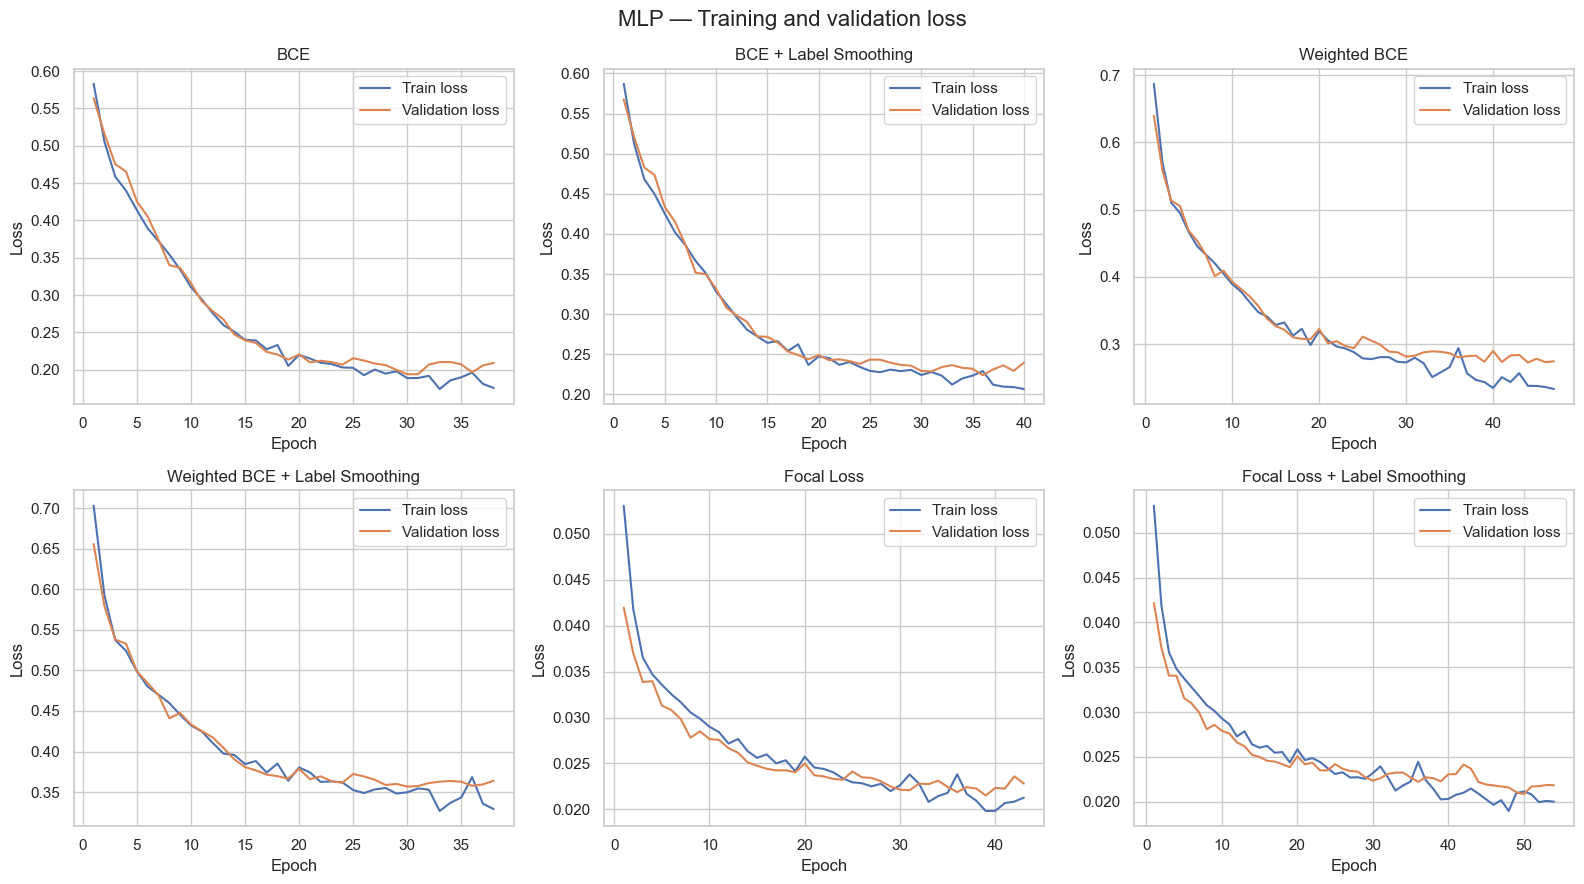

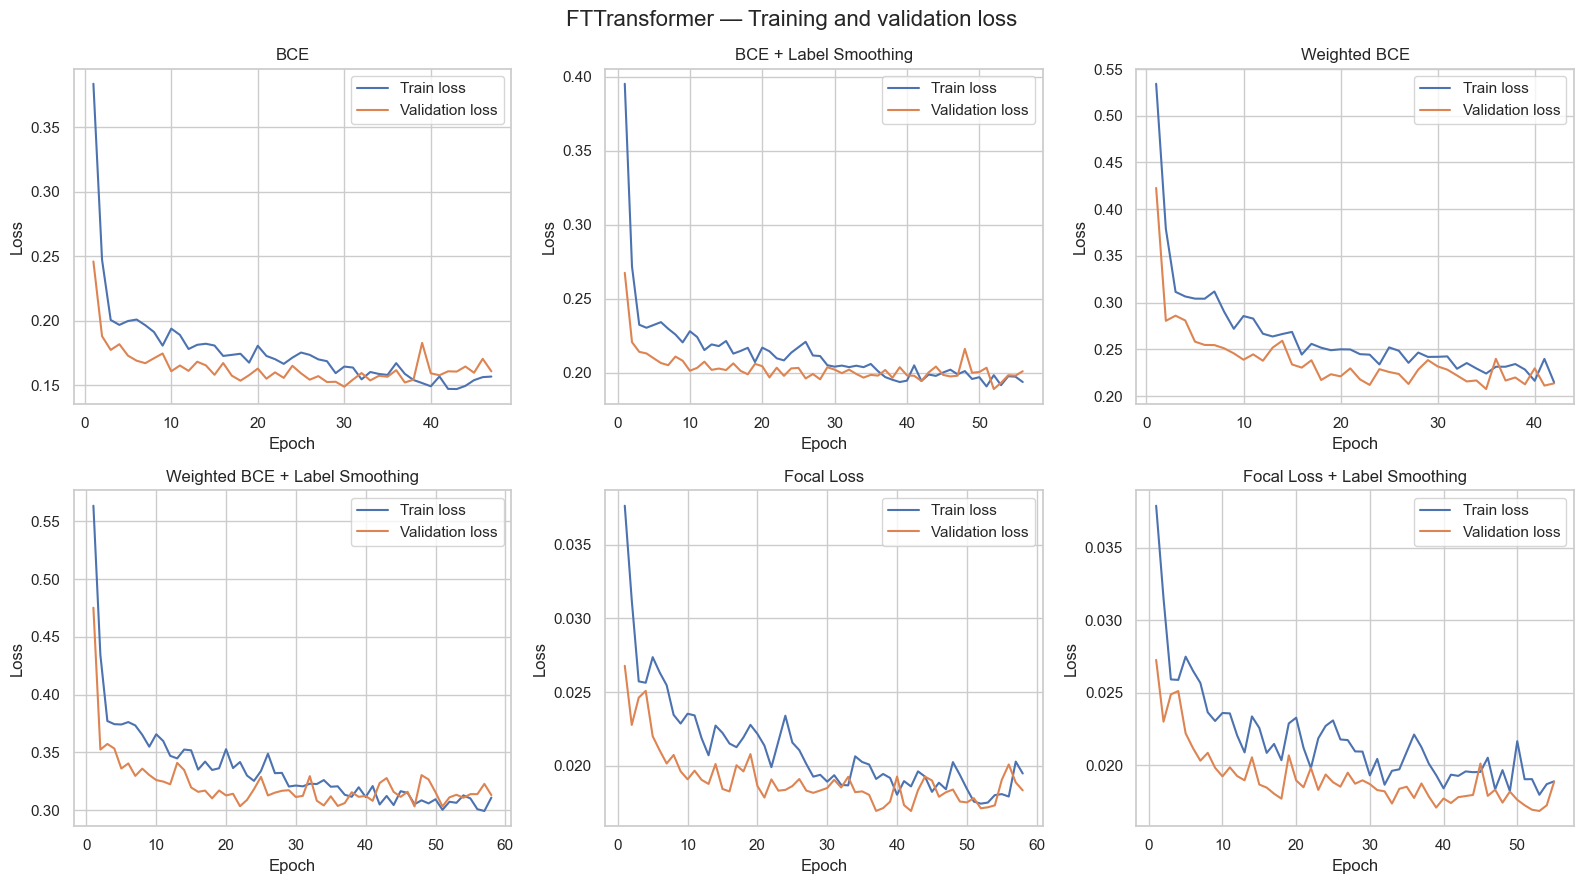

In [57]:
LOSS_STRATEGIES = [
    "BCE",
    "BCE + Label Smoothing",
    "Weighted BCE",
    "Weighted BCE + Label Smoothing",
    "Focal Loss",
    "Focal Loss + Label Smoothing",
]

for architecture in ["MLP", "FTTransformer"]:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for ax, strategy in zip(axes, LOSS_STRATEGIES):
        candidate = f"{architecture}|{strategy}"

        if candidate not in histories:
            ax.set_title(f"{strategy}\nNot running")
            ax.axis("off")
            continue

        history = histories[candidate]

        ax.plot(
            history["epoch"],
            history["train_loss"],
            label="Train loss",
        )
        ax.plot(
            history["epoch"],
            history["val_loss"],
            label="Validation loss",
        )

        ax.set_title(strategy)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()

    fig.suptitle(
        f"{architecture} — Training and validation loss",
        fontsize=16,
    )
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{architecture.lower()}_loss_curves.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()

## 8. So sánh trên validation set

Bảng được xếp hạng theo validation F1. Đây là bảng duy nhất dùng để chọn model tốt nhất; test metrics không tham gia model selection.


In [58]:
validation_metrics = (
    pd.DataFrame(validation_rows)
    .sort_values(["f1", "macro_f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)
validation_metrics.insert(0, "validation_rank", np.arange(1, len(validation_metrics) + 1))
validation_metrics.to_csv(METRIC_DIR / "dl_validation_metrics.csv", index=False)

epoch_loss_log = pd.concat(
    [history.assign(candidate=name) for name, history in histories.items()],
    ignore_index=True,
)
epoch_loss_log.to_csv(METRIC_DIR / "dl_epoch_loss_log.csv", index=False)

validation_metrics


,validation_rank,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,architecture,strategy
0,1,0.595,0.931532,0.714286,0.978261,0.825688,0.891544,0.978261,0.958893,FTTransformer|Weighted BCE,FTTransformer,Weighted BCE
1,2,0.640,0.931532,0.717742,0.967391,0.824074,0.890784,0.967391,0.958916,FTTransformer|BCE + Label Smoothing,FTTransformer,BCE + Label Smoothing
2,3,0.840,0.929730,0.705426,0.989130,0.823529,0.889830,0.989130,0.956850,FTTransformer|Weighted BCE + Label Smoothing,FTTransformer,Weighted BCE + Label Smoothing
3,4,0.695,0.931532,0.721311,0.956522,0.822430,0.890010,0.956522,0.959386,FTTransformer|Focal Loss,FTTransformer,Focal Loss
4,5,0.725,0.929730,0.712000,0.967391,0.820276,0.888302,0.967391,0.960935,FTTransformer|Focal Loss + Label Smoothing,FTTransformer,Focal Loss + Label Smoothing
5,6,0.645,0.927928,0.703125,0.978261,0.818182,0.886619,0.978261,0.958048,FTTransformer|BCE,FTTransformer,BCE
6,7,0.340,0.915315,0.671756,0.956522,0.789238,0.868125,0.956522,0.950770,MLP|BCE,MLP,BCE
7,8,0.610,0.917117,0.682540,0.934783,0.788991,0.868711,0.934783,0.952390,MLP|Weighted BCE + Label Smoothing,MLP,Weighted BCE + Label Smoothing
8,9,0.650,0.918919,0.697479,0.902174,0.786730,0.868337,0.902174,0.950864,MLP|Focal Loss + Label Smoothing,MLP,Focal Loss + Label Smoothing
9,10,0.640,0.915315,0.677165,0.934783,0.785388,0.866319,0.934783,0.950347,MLP|Focal Loss,MLP,Focal Loss


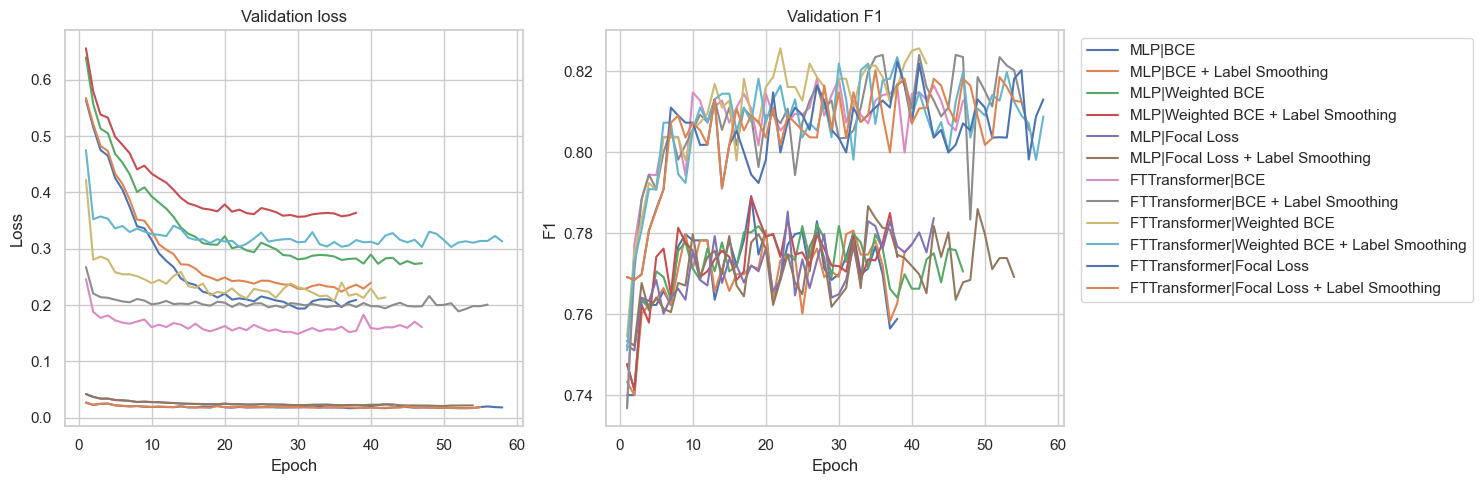

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for candidate, history in histories.items():
    axes[0].plot(history["epoch"], history["val_loss"], label=candidate)
    axes[1].plot(history["epoch"], history["val_f1"], label=candidate)

axes[0].set(title="Validation loss", xlabel="Epoch", ylabel="Loss")
axes[1].set(title="Validation F1", xlabel="Epoch", ylabel="F1")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dl_validation_curves.png", dpi=160, bbox_inches="tight")
plt.show()


## 9. Đánh giá cuối cùng trên test set

Model đứng đầu validation được chọn trước khi xem test metrics. Notebook báo cáo kết quả test của các experiment đã chạy để phân tích, nhưng giữ nguyên thứ tự validation rank nhằm tránh chọn lại model dựa trên test set.


In [60]:
test_rows = []
classification_reports = {}

for row in validation_metrics.itertuples(index=False):
    candidate = row.candidate
    model_pack = trained_models[candidate]
    test_prob, test_true = predict_proba(model_pack["model"], test_loader)
    metrics = compute_metrics(test_true, test_prob, model_pack["threshold"])
    metrics.update({
        "validation_rank": row.validation_rank,
        "candidate": candidate,
        "architecture": row.architecture,
        "strategy": row.strategy,
    })
    test_rows.append(metrics)

    test_pred = (test_prob >= model_pack["threshold"]).astype(int)
    classification_reports[candidate] = classification_report(
        test_true, test_pred, output_dict=True, zero_division=0
    )

test_metrics = pd.DataFrame(test_rows).sort_values("validation_rank").reset_index(drop=True)
test_metrics.to_csv(METRIC_DIR / "dl_test_metrics.csv", index=False)
test_metrics


,threshold,accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,validation_rank,candidate,architecture,strategy
0,0.595,0.915315,0.680000,0.923913,0.783410,0.865389,0.923913,0.954526,1,FTTransformer|Weighted BCE,FTTransformer,Weighted BCE
1,0.640,0.913514,0.680328,0.902174,0.775701,0.861065,0.902174,0.952672,2,FTTransformer|BCE + Label Smoothing,FTTransformer,BCE + Label Smoothing
2,0.840,0.915315,0.677165,0.934783,0.785388,0.866319,0.934783,0.951967,3,FTTransformer|Weighted BCE + Label Smoothing,FTTransformer,Weighted BCE + Label Smoothing
3,0.695,0.909910,0.681034,0.858696,0.759615,0.852092,0.858696,0.955935,4,FTTransformer|Focal Loss,FTTransformer,Focal Loss
4,0.725,0.915315,0.682927,0.913043,0.781395,0.864441,0.913043,0.955958,5,FTTransformer|Focal Loss + Label Smoothing,FTTransformer,Focal Loss + Label Smoothing
5,0.645,0.913514,0.674603,0.923913,0.779817,0.863002,0.923913,0.952202,6,FTTransformer|BCE,FTTransformer,BCE
6,0.340,0.893694,0.636364,0.836957,0.723005,0.828615,0.836957,0.941661,7,MLP|BCE,MLP,BCE
7,0.610,0.897297,0.647059,0.836957,0.729858,0.833227,0.836957,0.941990,8,MLP|Weighted BCE + Label Smoothing,MLP,Weighted BCE + Label Smoothing
8,0.650,0.893694,0.648649,0.782609,0.709360,0.822155,0.782609,0.945042,9,MLP|Focal Loss + Label Smoothing,MLP,Focal Loss + Label Smoothing
9,0.640,0.900901,0.652893,0.858696,0.741784,0.840234,0.858696,0.945230,10,MLP|Focal Loss,MLP,Focal Loss


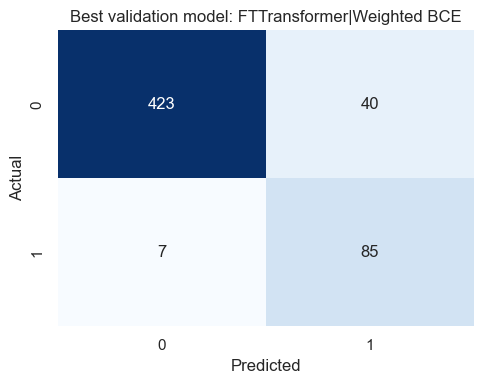

In [61]:
best_name = validation_metrics.iloc[0]["candidate"]
best_model = trained_models[best_name]["model"]
best_threshold = float(trained_models[best_name]["threshold"])

test_prob, test_true = predict_proba(best_model, test_loader)
test_pred = (test_prob >= best_threshold).astype(int)
confusion = confusion_matrix(test_true, test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Best validation model: {best_name}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dl_best_confusion_matrix.png", dpi=160)
plt.show()

pd.DataFrame(
    confusion,
    index=["actual_0", "actual_1"],
    columns=["pred_0", "pred_1"],
).to_csv(METRIC_DIR / "dl_best_confusion_matrix.csv")

pd.DataFrame(classification_reports[best_name]).T.to_csv(
    METRIC_DIR / "dl_best_classification_report.csv"
)


## 10. Export model

Artifact lưu state dict, threshold đã chọn trên validation và metadata cần cho inference. `architecture` và `strategy` cho biết chính xác cách dựng lại model và loss experiment thắng cuộc.


In [62]:
best_validation_row = validation_metrics.iloc[0]
best_artifact = {
    "model_name": best_name,
    "architecture": best_validation_row["architecture"],
    "strategy": best_validation_row["strategy"],
    "feature_cols": feature_cols,
    "input_dim": X_train.shape[1],
    "threshold": best_threshold,
    "pos_weight": pos_weight_value,
    "focal_alpha": focal_alpha,
    "focal_gamma": FOCAL_GAMMA,
    "label_smoothing": LABEL_SMOOTHING,
    "seed": SEED,
}

torch.save(
    {"state_dict": best_model.state_dict(), "metadata": best_artifact},
    MODEL_DIR / "best_dl_model.pt",
)
with (MODEL_DIR / "best_dl_model_meta.json").open("w", encoding="utf-8") as file:
    json.dump(best_artifact, file, indent=2, ensure_ascii=False)

exported_models = test_metrics.copy()
exported_models["artifact_path"] = ""
exported_models.loc[
    exported_models["candidate"] == best_name, "artifact_path"
] = "../models/dl/best_dl_model.pt"
exported_models.to_csv(MODEL_DIR / "exported_top_dl_models.csv", index=False)

best_artifact


{'model_name': 'FTTransformer|Weighted BCE',
 'architecture': 'FTTransformer',
 'strategy': 'Weighted BCE',
 'feature_cols': ['age',
  'gender',
  'daily_social_media_hours',
  'sleep_hours',
  'screen_time_before_sleep',
  'academic_performance',
  'physical_activity',
  'social_interaction_level',
  'stress_level',
  'anxiety_level',
  'platform_Both',
  'platform_Instagram',
  'platform_Other',
  'platform_TikTok',
  'sm_sleep_ratio',
  'screen_sleep_ratio',
  'heavy_sm_user',
  'low_sleep'],
 'input_dim': 18,
 'threshold': 0.595,
 'pos_weight': 5.009280742459397,
 'focal_alpha': 0.8335907335907335,
 'focal_gamma': 2.0,
 'label_smoothing': 0.05,
 'seed': 42}